<a href="https://colab.research.google.com/github/munozfloresnelsont12-oss/PPIA-github/blob/main/EX_ORDINARIO_PPIA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

NELSON TADEO MUÑOZ FLORES
2227010
N1-N3 25/05/26
"PROGRAMACION PARA INTELIGENCIA ARTIFICIAL"
**EXAMEN ORDINARIO**

**SECCION I.**
Responda cada una de las preguntas seleccionando la respuesta correcta.

1. c
2. b
3. b
4. a
5. a
6. c

**SECCION II.** Ejercicio Practico (Arbol de decisión)

UTILIZANDO EL DATASET "WINE", IMPLEMENTE UN CLASIFICADOR DE ARBOL DE DECISION.
1. UTILICE LOAD_WINE() DE SKLEARN.DATASETS Y CONVIERTALO A  UN DATAFRAME DE PANDAS.

In [5]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn import tree
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns
import numpy as np

In [16]:
import pandas as pd

Wine = load_wine()

df_wine = pd.DataFrame(data=Wine.data, columns=Wine.feature_names)

df_wine['target'] = Wine.target

df_wine['target_names'] = df_wine['target'].apply(lambda x: Wine.target_names[x])
print(df_wine.head())

   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proline  target target_names 

2. IDENTIFIQUE Y GESTIONE LOS VALORES NULOS (NAN) PRESENTES EN LA PRIMERA COLUMNA. JUSTIFIQUE BREVEMENTE QUE ESTRATEGIA UTILIZÓ.

In [17]:
print(df_wine.isnull().sum())
#EN ESTE CASO NO EXISTEN VALORES NULOS QUE GESTIONAR.

alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
target                          0
target_names                    0
dtype: int64


3. APLIQUE UNA TECNICA DE NORMALIZACION EN LAS 13 COLUMNAS DE ATRIBUTOS (STANDARDSCALER). DIVIDA EL DATASET EN UN CONJUNTO DE ENTRENAMIENTO (75%) Y UNO DE PRUEBA (25%) UTILIZANDO RANDOM_STATE=42.

In [19]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

X = df_wine.drop(['target', 'target_names'], axis=1)
y = df_wine['target']

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

X_train, X_test, y_train, y_test = train_test_split(X_scaled_df, y, test_size=0.25, random_state=42)

print("Los datos se normalizaron y se dividieron en conjuntos de entrenamiento y prueba.")
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")

Los datos se normalizaron y se dividieron en conjuntos de entrenamiento y prueba.
Shape of X_train: (133, 13)
Shape of X_test: (45, 13)


4. ENTRENE UN CLASIFICADOR DESICIONTREECLASSIFIER.

In [21]:
clf = DecisionTreeClassifier()
clf.fit(X_train, y_train)
train_accuracy = clf.score(X_train, y_train)
print(train_accuracy)

1.0


5. OBTENGA LA EXACTITUD DEL MODELO SOBRE EL CONJUNTO DE PRUEBA (ACCURACY_SCORE)

In [23]:
y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("Classification Report:\n", classification_report(y_test, y_pred, target_names=Wine.target_names))

Accuracy: 0.9333333333333333
Classification Report:
               precision    recall  f1-score   support

     class_0       1.00      0.87      0.93        15
     class_1       0.86      1.00      0.92        18
     class_2       1.00      0.92      0.96        12

    accuracy                           0.93        45
   macro avg       0.95      0.93      0.94        45
weighted avg       0.94      0.93      0.93        45



6. GENERE LA REPRESENTACION GRAFICA DEL ARBOL DE DESICION RESULTANTE MEDIANTE PLOT_TREE.

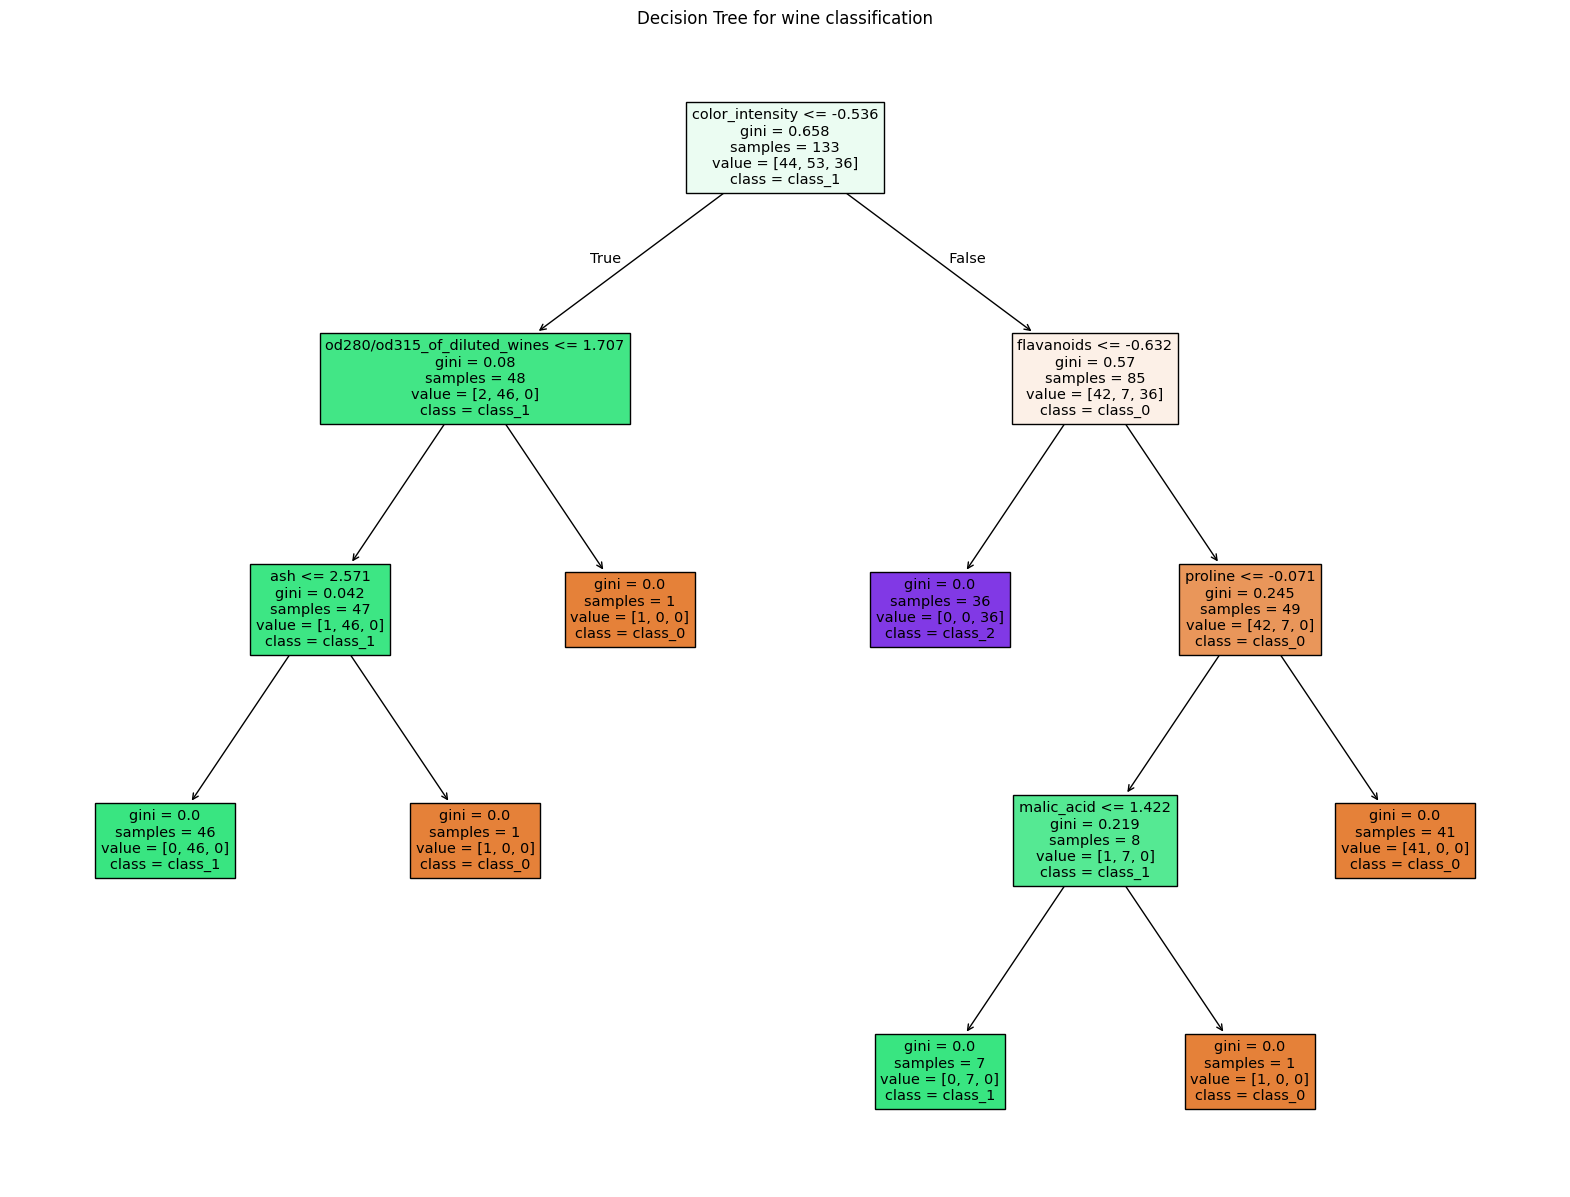

In [25]:
plt.figure(figsize=(20, 15))  # Increase figure size for better resolution
tree.plot_tree(clf, filled=True, feature_names=Wine.feature_names, class_names=Wine.target_names)
plt.title("Decision Tree for wine classification")
plt.savefig("decision_tree.png", dpi=300)  # Increase DPI for better resolution
plt.show()

7. OBSERVE LAS CARACTERISTICAS ELEGIDA EN EL NODO RAIZ, ¿QUE INDICA ESTO SOBRE LA IMPORTANCIA DE DICHO ATRIBUTO QUIMICO PARA LA CLASIFICACION DE LOS VINOS?

indica que la intensidad del color es el atributo químico más crítico para iniciar la clasificación de los vinos, como si fuera un filtro.